<a href="https://colab.research.google.com/github/gowreeshjgowreeshj/MEMORY-GAME/blob/main/OBJECT_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Fri Aug  7 12:03:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.5 MB/s eta 0:00:00


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("gowreeshs-workspace").project("biodegradable-nonbiodegradable-q8ncy")
version = project.version(1)
dataset = version.download("yolov5")

upload and label your dataset, and get an API KEY here: https://app.roboflow.com/?model=undefined&ref=undefined
loading Roboflow workspace...


RoboflowError: {"error":{"message":"This API key does not exist (or has been revoked).","status":401,"type":"OAuthException","hint":"You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours."}}

In [6]:
rf = Roboflow(api_key="Q7XJ4kdM2gx3oBjAJy1x")

In [7]:
project = rf.workspace("gowreeshs-workspace").project("biodegradable-nonbiodegradable-q8ncy")
version = project.version(1)
dataset = version.download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Biodegradable-&-NonBiodegradable-1 in yolov5pytorch:: 100%|██████████| 2033/2033 [00:00<00:00, 9817.59it/s] 


In [8]:
!find /content -name "data.yaml"

/content/Biodegradable-&-NonBiodegradable-1/data.yaml


In [9]:
%cd /content

!git clone https://github.com/ultralytics/yolov5.git

%cd yolov5

!pip install -qr requirements.txt

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 18689, done.
remote: Counting objects: 100% (301/301), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 18689 (delta 246), reused 128 (delta 128), pack-reused 18388 (from 3)
Receiving objects: 100% (18689/18689), 17.66 MiB | 27.23 MiB/s, done.
Resolving deltas: 100% (12731/12731), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 14.4 MB/s eta 0:00:00


In [10]:
!ls

AGENTS.md      CONTRIBUTING.md	LICENSE		 requirements.txt  utils
benchmarks.py  data		models		 segment	   val.py
CITATION.cff   detect.py	pyproject.toml	 tests
classify       export.py	README.md	 train.py
CLAUDE.md      hubconf.py	README.zh-CN.md  tutorial.ipynb


In [11]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 100 \
--data "/content/Biodegradable-&-NonBiodegradable-1/data.yaml" \
--weights yolov5s.pt \
--name biodegradable_detector

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/Biodegradable-&-NonBiodegradable-1/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=100, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval

In [12]:
!cat "/content/Biodegradable-&-NonBiodegradable-1/data.yaml"

names:
- biodegradable
- non-biodegradable
nc: 2
roboflow:
  license: CC BY 4.0
  project: biodegradable-nonbiodegradable-q8ncy
  url: https://universe.roboflow.com/gowreeshs-workspace/biodegradable-nonbiodegradable-q8ncy/dataset/1
  version: 1
  workspace: gowreeshs-workspace
test: ../test/images
train: Biodegradable-&-NonBiodegradable-1/train/images
val: Biodegradable-&-NonBiodegradable-1/valid/images


In [13]:
%%writefile "/content/Biodegradable-&-NonBiodegradable-1/data.yaml"
train: /content/Biodegradable-&-NonBiodegradable-1/train/images
val: /content/Biodegradable-&-NonBiodegradable-1/valid/images
test: /content/Biodegradable-&-NonBiodegradable-1/test/images

nc: 2

names:
  0: biodegradable
  1: non-biodegradable

Overwriting /content/Biodegradable-&-NonBiodegradable-1/data.yaml


In [14]:
!ls "/content/Biodegradable-&-NonBiodegradable-1/train/images" | head

cigarettebutt-10-_jpg.rf.f18054a5c08c1429dfb5cf3699b942ed.jpg
cigarettebutt-11-_jpg.rf.d535bc68d5ea4f35a50d6415a5664ee6.jpg
cigarettebutt-14-_jpg.rf.b5741ca9876c8e549611144b9280022a.jpg
cigarettebutt-16-_jpg.rf.7a6e7d9b07c6c7fd80dedf4bb1e55cd4.jpg
cigarettebutt-17-_jpg.rf.9c25bfd62e450de0a7946a95936e0562.jpg
cigarettebutt-19-_jpg.rf.71c8f7bb1c5e9a56a62f0f2a7677bc4a.jpg
cigarettebutt-1-_jpg.rf.63269cb4f997fef023102f3414ff6dea.jpg
cigarettebutt-20-_jpg.rf.e962f223cbe1caec794ac75c9622a8a0.jpg
cigarettebutt-21-_jpg.rf.83905d64fe83eb489dc4b3b21f9b41c1.jpg
cigarettebutt-22-_jpg.rf.40286f54cbae5c0e8c36fc7c702a6ce8.jpg


In [15]:
%cd /content/yolov5
.


-n.py \
--img 640 \
--batch 16 \
--epochs 100 \
--data "/content/Biodegradable-&-NonBiodegradable-1/data.yaml" \
--weights yolov5s.pt \
--name biodegradable_detector

/content/yolov5
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/Biodegradable-&-NonBiodegradable-1/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=100, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=biodegradable_detector, exist_ok=Fal

In [16]:
!ls runs/train/biodegradable_detector2/weights

best.pt  last.pt


In [17]:
from google.colab import files
files.download("runs/train/biodegradable_detector2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
!python detect.py \
--weights runs/train/biodegradable_detector2/weights/best.pt \
--img 640 \
--conf 0.25 \
--source /content/1706643291230.webp

detect: weights=['runs/train/biodegradable_detector2/weights/best.pt'], source=/content/1706643291230.webp, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-544-g20d1d78a Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/1706643291230.webp: 480x640 1 biodegradable, 34.0ms
Speed: 0.5ms pre-process, 34.0ms inference, 113.8ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp


In [20]:
!python detect.py \
--weights runs/train/biodegradable_detector2/weights/best.pt \
--source /content/1706643291230.webp

detect: weights=['runs/train/biodegradable_detector2/weights/best.pt'], source=/content/1706643291230.webp, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-544-g20d1d78a Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/1706643291230.webp: 480x640 1 biodegradable, 35.6ms
Speed: 0.7ms pre-process, 35.6ms inference, 93.1ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


In [22]:
!python detect.py \
--weights runs/train/biodegradable_detector2/weights/best.pt \
--source /content/bottle.jpg

detect: weights=['runs/train/biodegradable_detector2/weights/best.pt'], source=/content/bottle.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-544-g20d1d78a Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/bottle.jpg: 640x640 1 biodegradable, 1 non-biodegradable, 10.1ms
Speed: 0.6ms pre-process, 10.1ms inference, 112.4ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp3


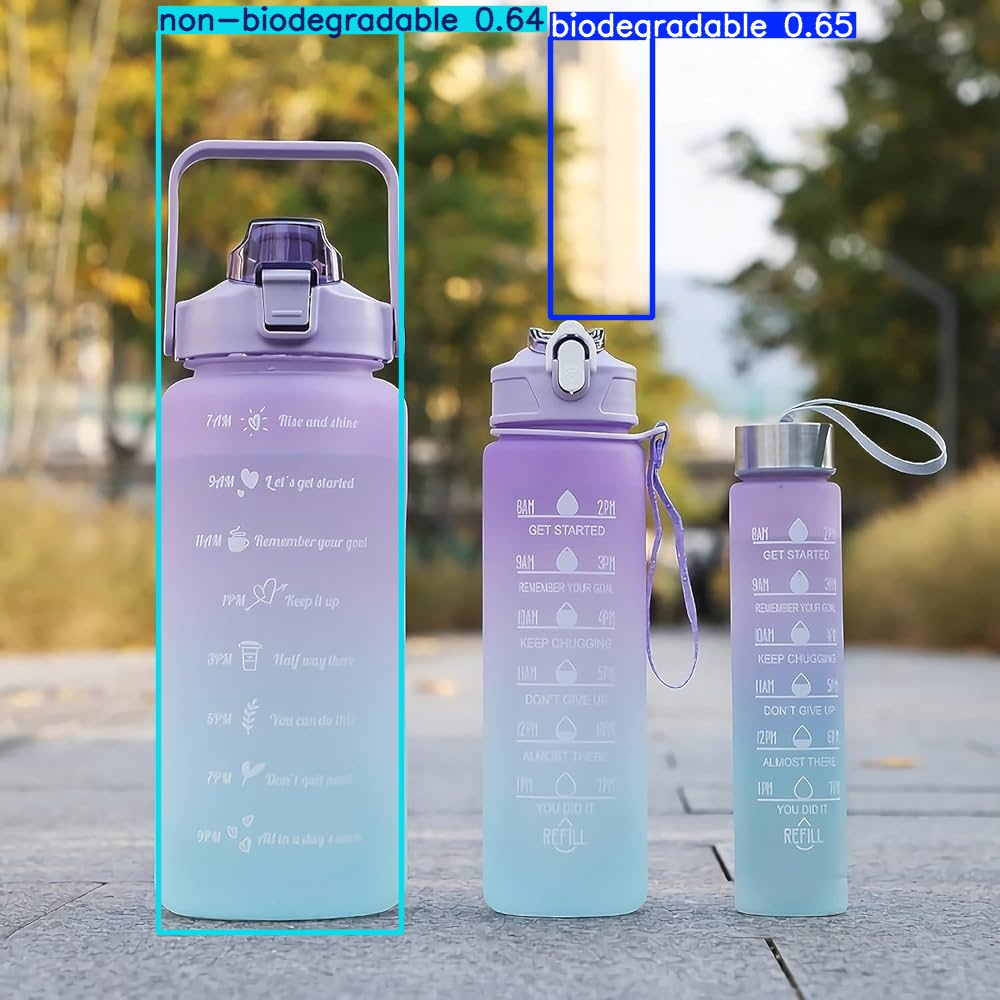

In [23]:
from IPython.display import Image, display

display(Image(filename="runs/detect/exp3/bottle.jpg"))